In [ ]:
#Word2Vec
import numpy as np
#numpy vektor ve matrısler uzerıne ıslem yapmamızı sağlar
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [ ]:
f = open('Alice.txt', 'r', encoding='utf8')
text = f.read()
t_list = text.split('\n')

corpus = []

for cumle in t_list:
    corpus.append(cumle.split())
print(corpus[:10])

[['\ufeffThe', 'Project', 'Gutenberg', 'eBook', 'of', 'Alice’s', 'Adventures', 'in', 'Wonderland,', 'by', 'Lewis', 'Carroll'], [], ['This', 'eBook', 'is', 'for', 'the', 'use', 'of', 'anyone', 'anywhere', 'in', 'the', 'United', 'States', 'and'], ['most', 'other', 'parts', 'of', 'the', 'world', 'at', 'no', 'cost', 'and', 'with', 'almost', 'no', 'restrictions'], ['whatsoever.', 'You', 'may', 'copy', 'it,', 'give', 'it', 'away', 'or', 're-use', 'it', 'under', 'the', 'terms'], ['of', 'the', 'Project', 'Gutenberg', 'License', 'included', 'with', 'this', 'eBook', 'or', 'online', 'at'], ['www.gutenberg.org.', 'If', 'you', 'are', 'not', 'located', 'in', 'the', 'United', 'States,', 'you'], ['will', 'have', 'to', 'check', 'the', 'laws', 'of', 'the', 'country', 'where', 'you', 'are', 'located', 'before'], ['using', 'this', 'eBook.'], []]


In [ ]:
model = Word2Vec(corpus, vector_size=100, window=5, min_count=1) # CBOW

In [ ]:
import sklearn
import pandas as pd

# Visualization using tsne plots:
## converting into suitable dimensions for plotting
# Reduce dimensions to 2 to visualize the data
tsne = sklearn.manifold.TSNE(n_components=2, random_state=0)
all_word_vectors_matrix = model.wv.vectors
all_word_vectors_matrix_2d = tsne.fit_transform(all_word_vectors_matrix)

# Creating a dataframe with all the words and their coordinates for a manual
# visualization in converted dimensions.
points = pd.DataFrame([
    (word, coords[0], coords[1])
    for word, coords in [
        (word, all_word_vectors_matrix_2d[model.wv.key_to_index[word]])
        for word in model.wv.key_to_index
    ]
],
    columns=["word", "x", "y"]
)
points.head(10)

,word,x,y
0,the,70.690659,32.047852
1,and,70.516518,32.152966
2,to,70.475365,32.174961
3,a,70.546410,32.134602
4,of,70.367050,32.234966
5,she,69.428673,32.780579
6,said,70.346443,32.248222
7,in,70.162537,32.354530
8,it,69.794937,32.569630
9,was,67.915024,33.619923


<Axes: title={'center': 'Complete embedding space TSNE plot'}, xlabel='x', ylabel='y'>

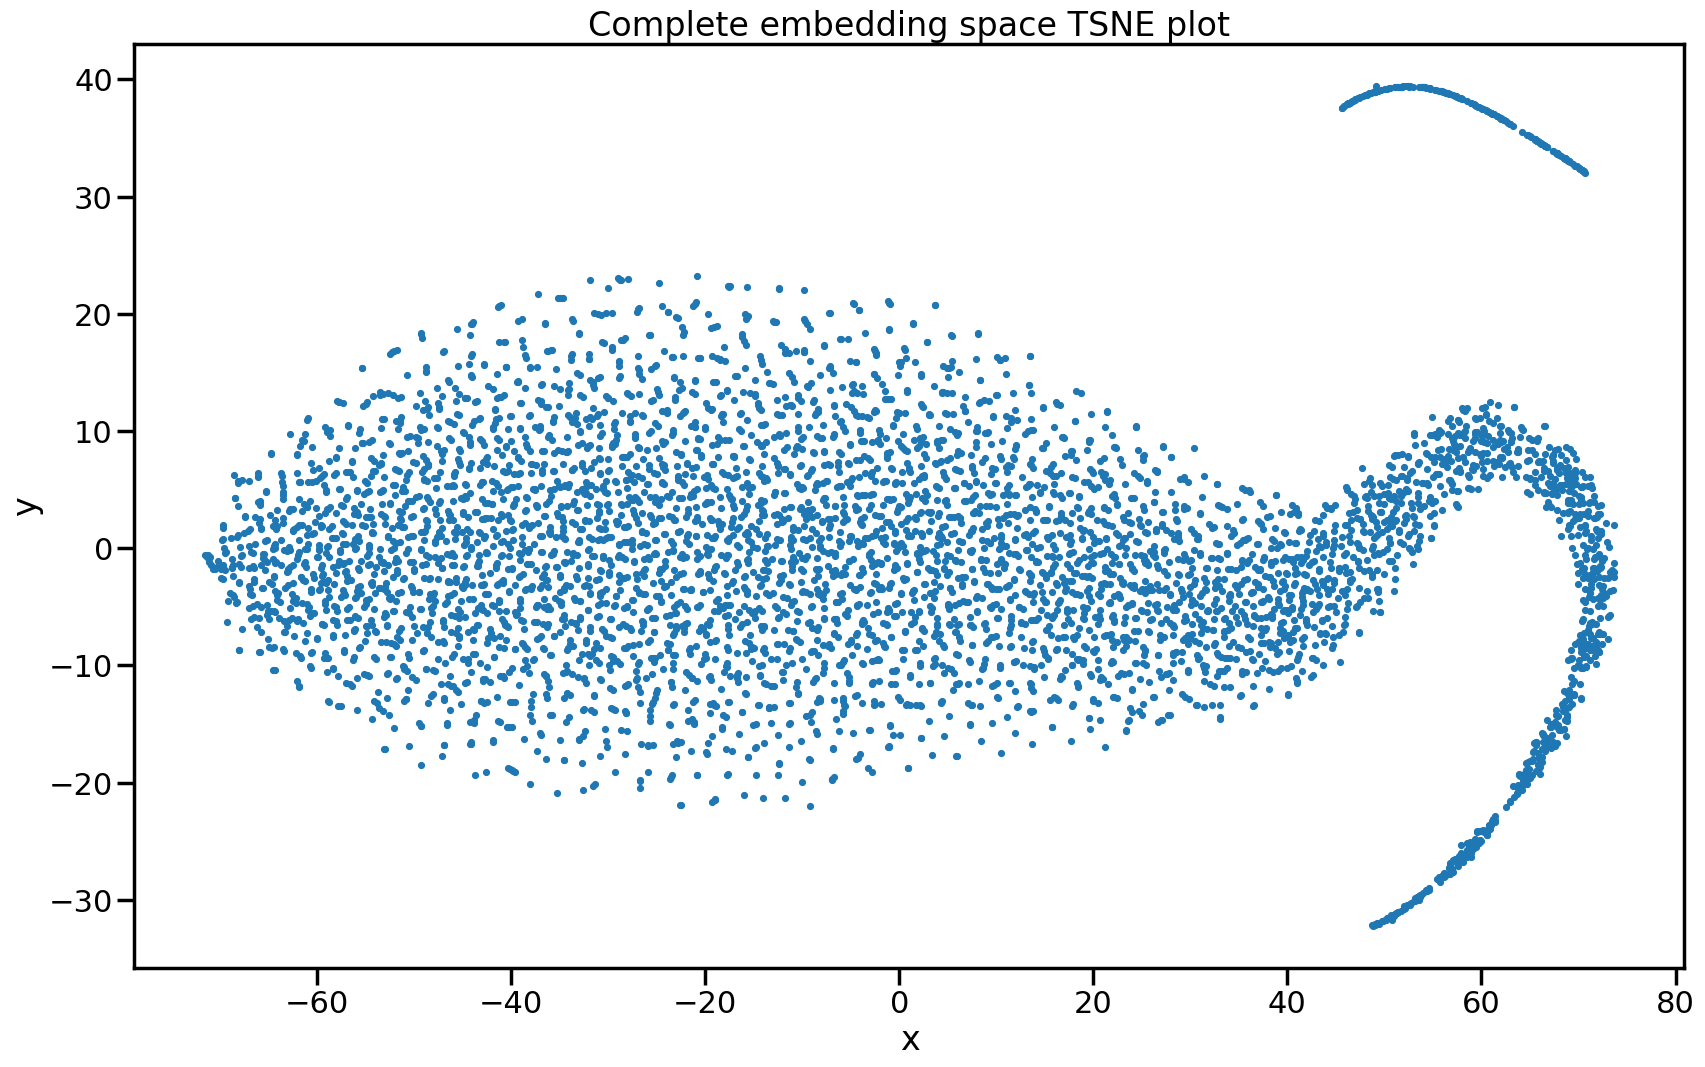

In [ ]:
import seaborn as sns
# tsne plot
sns.set_context("poster")
points.plot.scatter("x", "y", s=10, figsize=(20, 12), title="Complete embedding space TSNE plot")

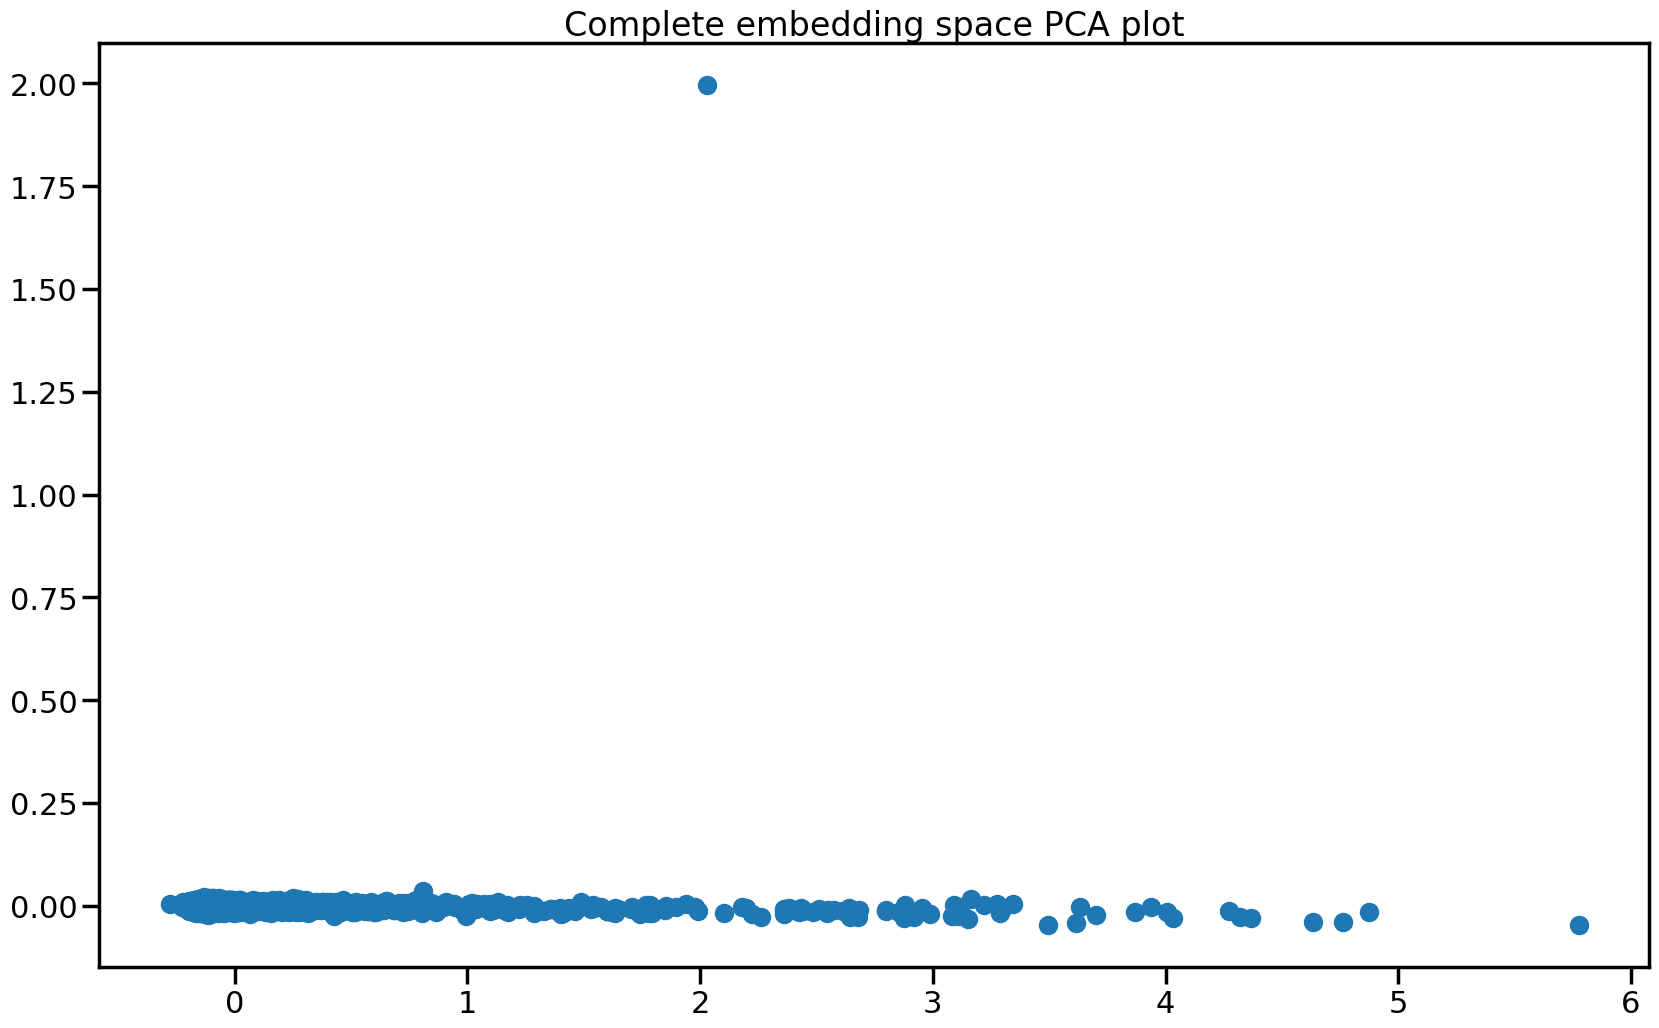

In [ ]:
from sklearn.decomposition import PCA
# fit a 2d PCA model to the vectors
vocab = list(model.wv.key_to_index)
X = model.wv[vocab]
pca = PCA(n_components=2)
result = pca.fit_transform(X)
plt.figure(figsize=(20,12))
plt.title("Complete embedding space PCA plot")
# create a scatter plot of the projection
plt.scatter(result[:, 0], result[:, 1])
words = list(model.wv.key_to_index)
plt.show()

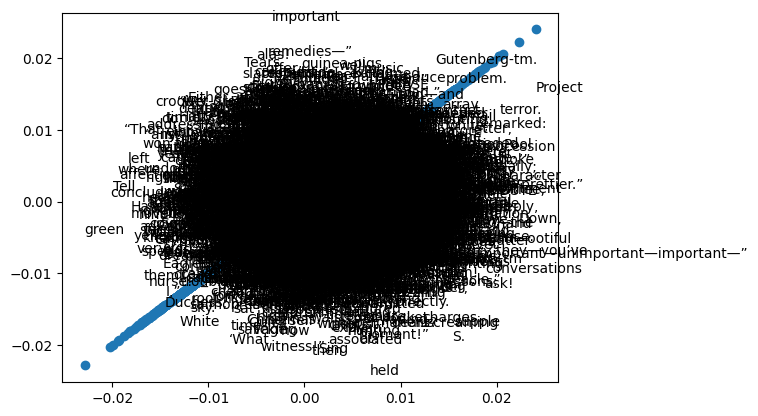

In [ ]:
from sklearn.decomposition import PCA
from matplotlib import pyplot
# fit a 2d PCA model to the vectors
#X = model[model.wv.vocab]
vocab = list(model.wv.key_to_index)
X = model.wv[vocab]
pca = PCA(n_components=5)
result = pca.fit_transform(X)
# create a scatter plot of the projection
pyplot.scatter(result[:,-1], result[:, 4])
words = list(model.wv.key_to_index)
for i, word in enumerate(words):
	pyplot.annotate(word, xy=(result[i, -1], result[i, 3]))
pyplot.show()